In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from yellowbrick.cluster import KElbowVisualizer
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("Instagram visits clustering.csv")
df.head()

,User ID,Instagram visit score,Spending_rank(0 to 100)
0,0,63,24.050708
1,1,61,25.223290
2,2,104,18.528245
3,3,82,86.890232
4,4,14,31.492397


In [3]:
#check duplicate row
df.duplicated().sum()

np.int64(0)

In [4]:
print(df.columns)


Index(['User ID', 'Instagram visit score', 'Spending_rank(0 to 100)'], dtype='object')


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   User ID                  2600 non-null   int64  
 1   Instagram visit score    2600 non-null   int64  
 2   Spending_rank(0 to 100)  2600 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 61.1 KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
User ID,2600.0,1299.500000,750.699674,0.000000,649.750000,1299.500000,1949.250000,2599.000000
Instagram visit score,2600.0,63.323462,26.579760,5.000000,38.000000,72.000000,86.000000,118.000000
Spending_rank(0 to 100),2600.0,42.848408,28.758349,0.940709,19.452098,28.013082,72.116945,107.349821


In [7]:
numeric_columns = ['Instagram visit score', 'Spending_rank(0 to 100)']

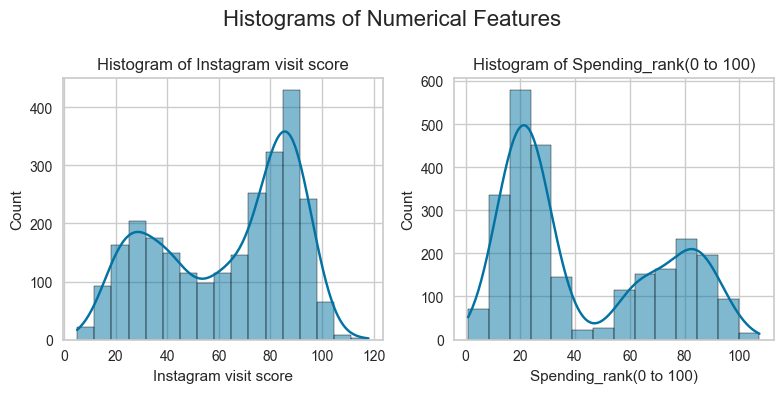

In [8]:
#check features distribution

#create grid size

rows, cols = 1, 2

# create figure and subplots
plt.figure(figsize=(8, 4))

# plot each feature in subplot
for i, col in enumerate(numeric_columns, 1):
    plt.subplot(rows, cols, i)
    sns.histplot(df[col], kde=True)
    plt.title(f"Histogram of {col}")

# layout
plt.suptitle("Histograms of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

<Axes: xlabel='Instagram visit score', ylabel='Spending_rank(0 to 100)'>

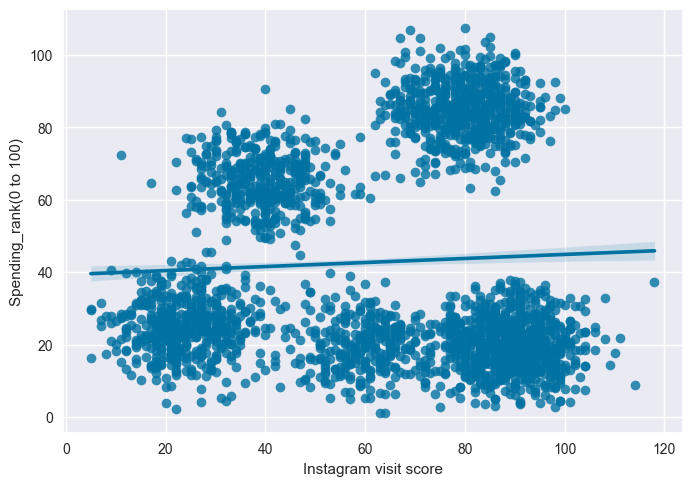

In [9]:


# ==================================
# check correlation between features
# ==================================
sns.set_style('darkgrid')
sns.regplot(x='Instagram visit score', y='Spending_rank(0 to 100)', data=df)



In [10]:


# =============
# check outlier
# =============

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(outliers)
    
    df = df.drop(outliers.index)



Empty DataFrame
Columns: [User ID, Instagram visit score, Spending_rank(0 to 100)]
Index: []
Empty DataFrame
Columns: [User ID, Instagram visit score, Spending_rank(0 to 100)]
Index: []


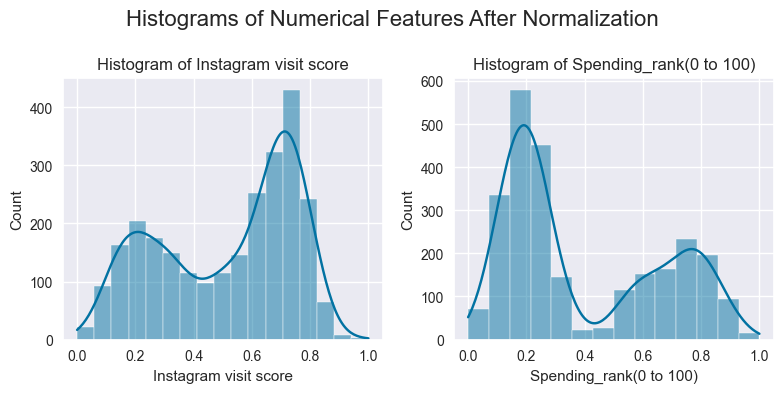

In [11]:
# normalization features using min-max scaler
scaler = MinMaxScaler()
user_data_scaled = df.copy()
user_data_scaled[numeric_columns] = scaler.fit_transform(df[numeric_columns])

# ===============================================
# check features distribution after normalization
# ===============================================

# create grid size
rows, cols = 1, 2

# create figure and subplots
plt.figure(figsize=(8, 4))

# plot each feature in subplot
for i, col in enumerate(numeric_columns, 1):
    plt.subplot(rows, cols, i)
    sns.histplot(user_data_scaled[col], kde=True)
    plt.title(f"Histogram of {col}")

# layout
plt.suptitle("Histograms of Numerical Features After Normalization", fontsize=16)
plt.tight_layout()
plt.show()

In [12]:
# create variable for dataset we will use in modeling

X = user_data_scaled.copy()
X = X.drop('User ID', axis=1)

In [13]:
# Model Training 

model_1 = KMeans(random_state = 0)
model_1.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",8
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [14]:
# get cluster labels 

labels = model_1.labels_

# number of cluster

k = len(model_1.cluster_centers_)

# create function for analyzing characteristics of each cluster

def analyze_clusters(X, labels, k):
    print("Characteristics of each clusters: ")
    for cluster_id in range(k):
        #get current cluster data
        cluster_data = X[labels == cluster_id]

         # get means for each feature in cluster
        print(f'\nCluster {cluster_id + 1}:')
        mean_values = cluster_data.mean()  # use .mean() from pandas
        for col in X.columns:
            print(f'Mean of {col}: {mean_values[col]:.2f}')

# analyze characteristics of each cluster
analyze_clusters(X, labels, k)

Characteristics of each clusters: 

Cluster 1:
Mean of Instagram visit score: 0.66
Mean of Spending_rank(0 to 100): 0.79

Cluster 2:
Mean of Instagram visit score: 0.48
Mean of Spending_rank(0 to 100): 0.18

Cluster 3:
Mean of Instagram visit score: 0.32
Mean of Spending_rank(0 to 100): 0.55

Cluster 4:
Mean of Instagram visit score: 0.79
Mean of Spending_rank(0 to 100): 0.19

Cluster 5:
Mean of Instagram visit score: 0.19
Mean of Spending_rank(0 to 100): 0.27

Cluster 6:
Mean of Instagram visit score: 0.28
Mean of Spending_rank(0 to 100): 0.66

Cluster 7:
Mean of Instagram visit score: 0.14
Mean of Spending_rank(0 to 100): 0.18

Cluster 8:
Mean of Instagram visit score: 0.68
Mean of Spending_rank(0 to 100): 0.16


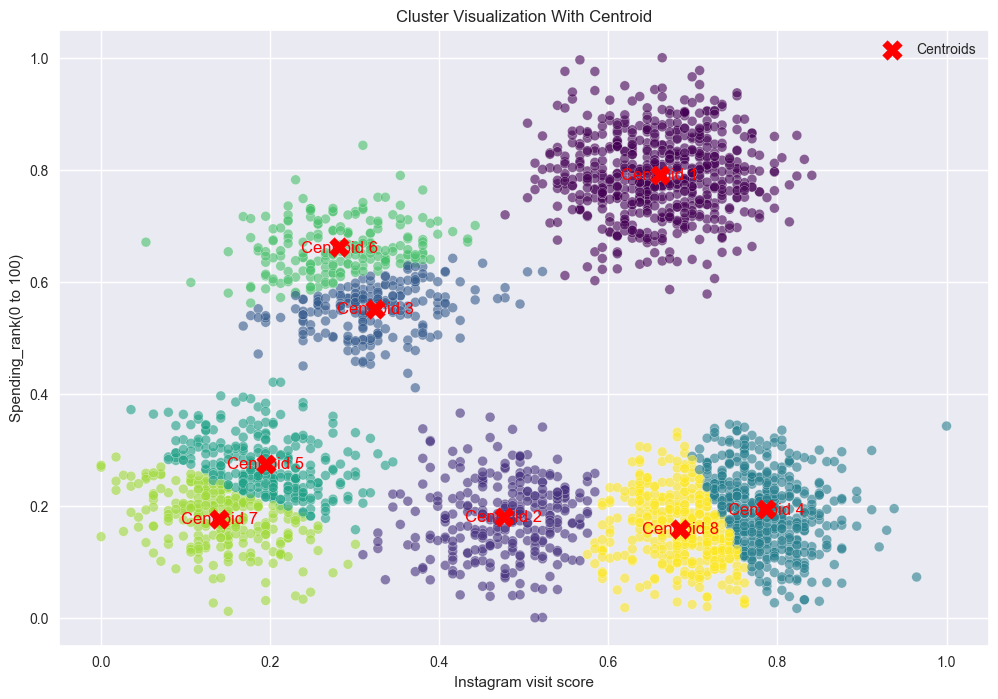

Centroids Value:
Centroid 1: Instagram visit score = 0.66, Spending_rank(0 to 100) = 0.79
Centroid 2: Instagram visit score = 0.48, Spending_rank(0 to 100) = 0.18
Centroid 3: Instagram visit score = 0.32, Spending_rank(0 to 100) = 0.55
Centroid 4: Instagram visit score = 0.79, Spending_rank(0 to 100) = 0.19
Centroid 5: Instagram visit score = 0.20, Spending_rank(0 to 100) = 0.27
Centroid 6: Instagram visit score = 0.28, Spending_rank(0 to 100) = 0.66
Centroid 7: Instagram visit score = 0.14, Spending_rank(0 to 100) = 0.18
Centroid 8: Instagram visit score = 0.69, Spending_rank(0 to 100) = 0.16


In [15]:
# create numpy array of X for plotting purpose
X_np = np.array(X)

# get centroid position
centroids = model_1.cluster_centers_

# visualize cluster
plt.figure(figsize=(12, 8))
 
# plot data
plt.scatter(X_np[:, 0], X_np[:, 1], c=labels, cmap='viridis', s=50, alpha=0.6, edgecolors='w', marker='o')
 
# plot centroid
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')

# add centroid label on plot
for i, centroid in enumerate(centroids):
    plt.text(centroid[0], centroid[1], f'Centroid {i+1}', color='red', fontsize=12, ha='center', va='center')
 
# add title and label
plt.title('Cluster Visualization With Centroid')
plt.xlabel('Instagram visit score')
plt.ylabel('Spending_rank(0 to 100)')
plt.legend()
 
plt.show()
 
# print centroid value
print("Centroids Value:")
for i, centroid in enumerate(centroids):
    print(f"Centroid {i+1}: Instagram visit score = {centroid[0]:.2f}, Spending_rank(0 to 100) = {centroid[1]:.2f}")

In [22]:
from sklearn.base import is_clusterer
print(is_clusterer(model_1))

True


In [23]:
print(type(model_1))


<class 'sklearn.cluster._kmeans.KMeans'>


In [25]:



# initialize KElbow visualizer for getting optimal cluster number
visualizer = KElbowVisualizer(model_1, k=(1, 11))
 
# Fit visualizer with data
visualizer.fit(X)
 
# show elbow plot for analysis
visualizer.show()
plt.show()



YellowbrickTypeError: The supplied model is not a clustering estimator; try a classifier or regression score visualizer instead!